### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_2d, rotate_cov_2d, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [2]:
N = 3
m = 2
phi_deg = 75.0
n_samples = 10001
X_seed = 0
# get /sigma
Sigma = np.array([[3.0, 1.2],
                    [1.2, 1.0]])
Sigma_rot = rotate_cov_2d(Sigma, np.deg2rad(phi_deg))

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# eigen vectors of X before and X after
print(f"Eigen vectors of X before: {pca_before.components_}")
print(f"Eigen vectors of X after: {pca_after.components_}")



Eigen values of X before: [3.52626641 0.43540967]
Eigen values of X after: [3.64132268 0.44158559]
Eigen vectors of X before: [[ 0.4302492   0.81711148  0.38368535]
 [-0.37507937 -0.22479179  0.89932426]]
Eigen vectors of X after: [[-0.47474411 -0.43111871  0.76730352]
 [ 0.31688632  0.72961578  0.6060065 ]]


### Apply Leen's complete model to before and after drifted models

In [3]:
from hebbian.models import LeenCompletePCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

In [4]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-5,          # base
    eta_v=2e-3,          # ~4x eta_w
    C=2.0,
    ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-5,
    eta_v=2e-4,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

### Multiple runs

In [5]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True)
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True)
        print(f"after second phase: model.W = {model.W}; model.V = {model.V}")
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

run  1
X_before
step    0 | order = [1 0] | best|corr|= [0.89  0.426]
step 1000 | order = [0 1] | best|corr|= [0.998 0.865]
step 2000 | order = [0 1] | best|corr|= [0.995 0.93 ]
step 3000 | order = [0 1] | best|corr|= [1.    0.962]
step 4000 | order = [0 1] | best|corr|= [0.996 0.971]
step 5000 | order = [0 1] | best|corr|= [0.998 0.979]
step 6000 | order = [0 1] | best|corr|= [0.994 0.982]
step 7000 | order = [0 1] | best|corr|= [1.    0.987]
step 8000 | order = [0 1] | best|corr|= [0.987 0.991]
step 9000 | order = [0 1] | best|corr|= [0.997 0.991]
step 10000 | order = [0 1] | best|corr|= [0.941 0.995]


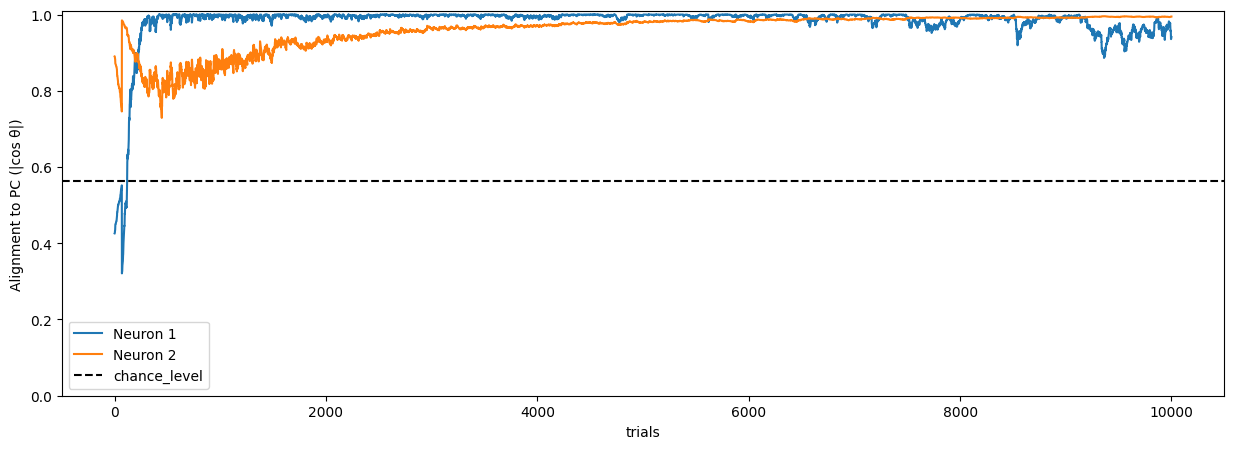

X_after
step    0 | order = [0 1] | best|corr|= [0.999 0.847]
step 1000 | order = [0 1] | best|corr|= [0.952 0.809]
step 2000 | order = [0 1] | best|corr|= [0.975 0.876]
step 3000 | order = [0 1] | best|corr|= [0.98 0.82]
step 4000 | order = [0 1] | best|corr|= [0.99  0.892]
step 5000 | order = [0 1] | best|corr|= [0.99  0.793]
step 6000 | order = [0 1] | best|corr|= [0.994 0.83 ]
step 7000 | order = [0 1] | best|corr|= [0.997 0.882]
step 8000 | order = [0 1] | best|corr|= [0.997 0.834]
step 9000 | order = [0 1] | best|corr|= [0.999 0.884]
step 10000 | order = [0 1] | best|corr|= [0.999 0.908]


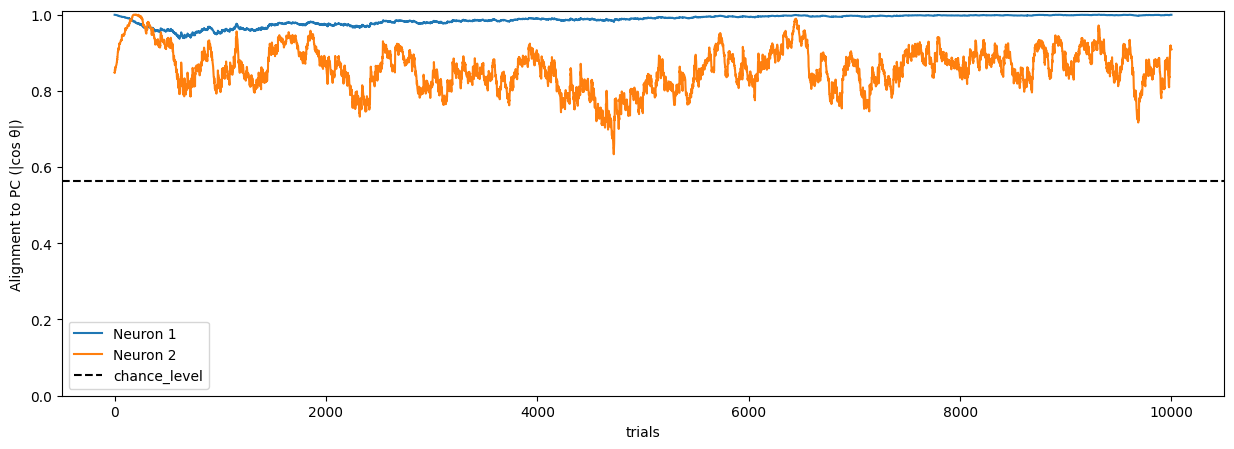

after second phase: model.W = [[-0.43819186 -0.34281215  0.80529378]
 [-0.25114939 -0.75097715 -0.46747481]]; model.V = [[ 0.         -0.12576645]
 [-0.12576645  0.        ]]
run  2
X_before
step    0 | order = [1 0] | best|corr|= [0.999 0.647]
step 1000 | order = [0 1] | best|corr|= [0.924 0.868]
step 2000 | order = [0 1] | best|corr|= [0.823 0.94 ]
step 3000 | order = [0 1] | best|corr|= [0.765 0.966]
step 4000 | order = [0 1] | best|corr|= [0.744 0.979]
step 5000 | order = [0 1] | best|corr|= [0.713 0.984]
step 6000 | order = [0 1] | best|corr|= [0.712 0.988]
step 7000 | order = [0 1] | best|corr|= [0.722 0.99 ]
step 8000 | order = [0 1] | best|corr|= [0.754 0.992]
step 9000 | order = [0 1] | best|corr|= [0.751 0.993]
step 10000 | order = [0 1] | best|corr|= [0.823 0.994]


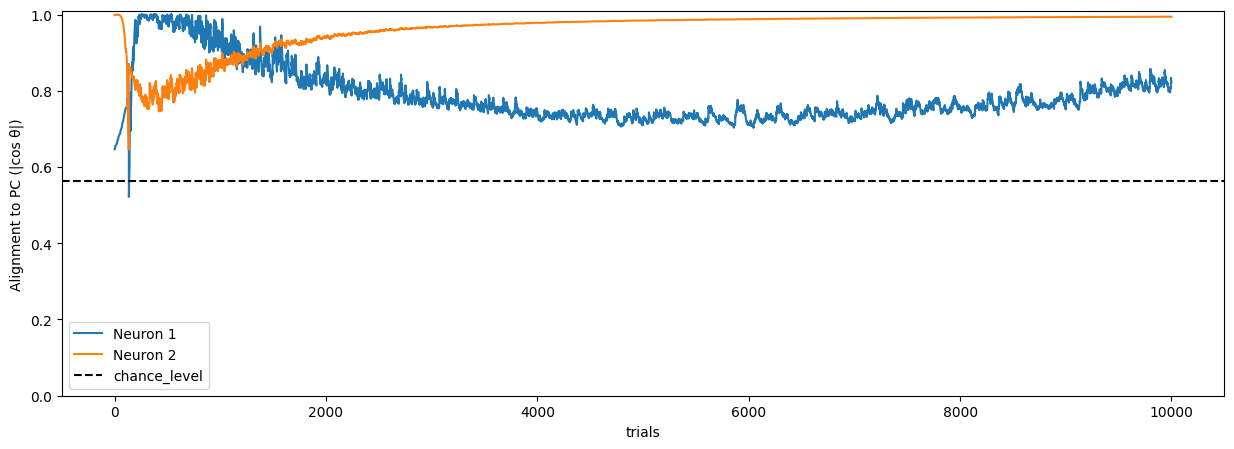

X_after
step    0 | order = [0 1] | best|corr|= [0.988 0.838]
step 1000 | order = [1 0] | best|corr|= [0.749 0.778]
step 2000 | order = [1 0] | best|corr|= [0.943 0.814]
step 3000 | order = [1 0] | best|corr|= [0.988 0.854]
step 4000 | order = [1 0] | best|corr|= [0.998 0.885]
step 5000 | order = [1 0] | best|corr|= [0.995 0.912]
step 6000 | order = [1 0] | best|corr|= [0.993 0.932]
step 7000 | order = [1 0] | best|corr|= [0.99  0.949]
step 8000 | order = [1 0] | best|corr|= [0.998 0.961]
step 9000 | order = [1 0] | best|corr|= [0.988 0.97 ]
step 10000 | order = [1 0] | best|corr|= [0.992 0.977]


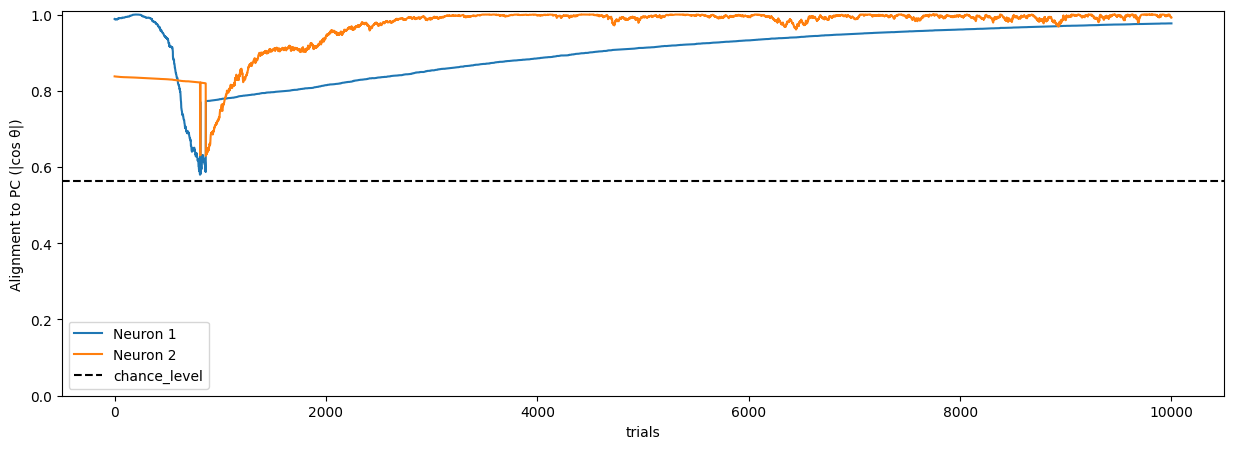

after second phase: model.W = [[ 0.46058433 -0.39361103  0.00456079]
 [-0.55293465 -0.70995743  0.41866731]]; model.V = [[0.         0.08324807]
 [0.08324807 0.        ]]
run  3
X_before
step    0 | order = [1 0] | best|corr|= [0.997 0.788]
step 1000 | order = [1 0] | best|corr|= [1.    0.967]
step 2000 | order = [1 0] | best|corr|= [1.    0.971]
step 3000 | order = [1 0] | best|corr|= [1.    0.904]
step 4000 | order = [1 0] | best|corr|= [1.   0.97]
step 5000 | order = [1 0] | best|corr|= [1.    0.939]
step 6000 | order = [1 0] | best|corr|= [0.999 0.983]
step 7000 | order = [1 0] | best|corr|= [0.999 0.961]
step 8000 | order = [1 0] | best|corr|= [1.    0.904]
step 9000 | order = [1 0] | best|corr|= [0.999 0.955]
step 10000 | order = [1 0] | best|corr|= [1.    0.852]


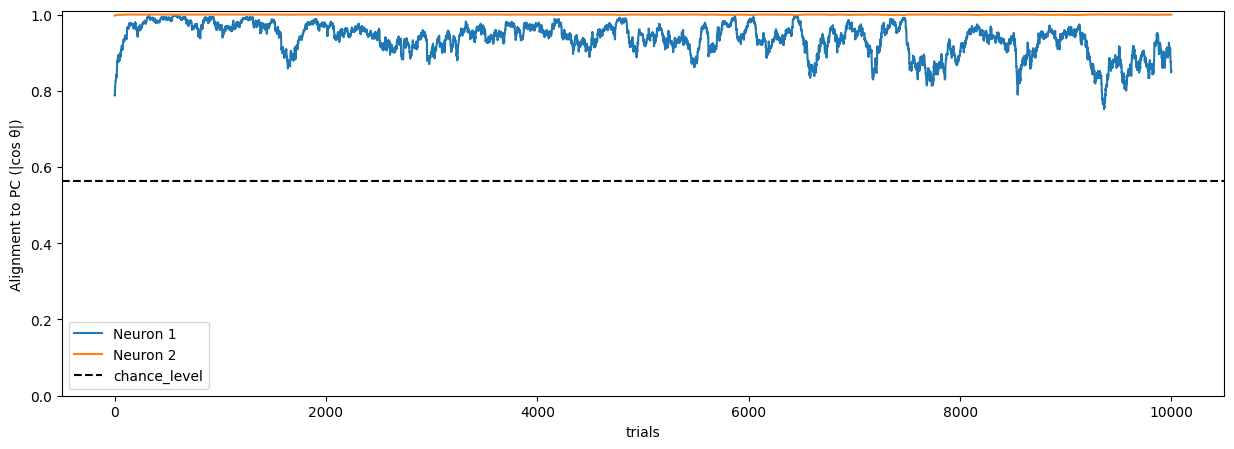

X_after
step    0 | order = [1 0] | best|corr|= [0.996 0.998]
step 1000 | order = [1 0] | best|corr|= [0.823 0.989]
step 2000 | order = [1 0] | best|corr|= [0.9   0.994]
step 3000 | order = [1 0] | best|corr|= [0.846 0.994]
step 4000 | order = [1 0] | best|corr|= [0.928 0.998]
step 5000 | order = [1 0] | best|corr|= [0.83  0.997]
step 6000 | order = [1 0] | best|corr|= [0.877 0.998]
step 7000 | order = [1 0] | best|corr|= [0.92  0.999]
step 8000 | order = [1 0] | best|corr|= [0.869 0.999]
step 9000 | order = [1 0] | best|corr|= [0.914 1.   ]
step 10000 | order = [1 0] | best|corr|= [0.932 1.   ]


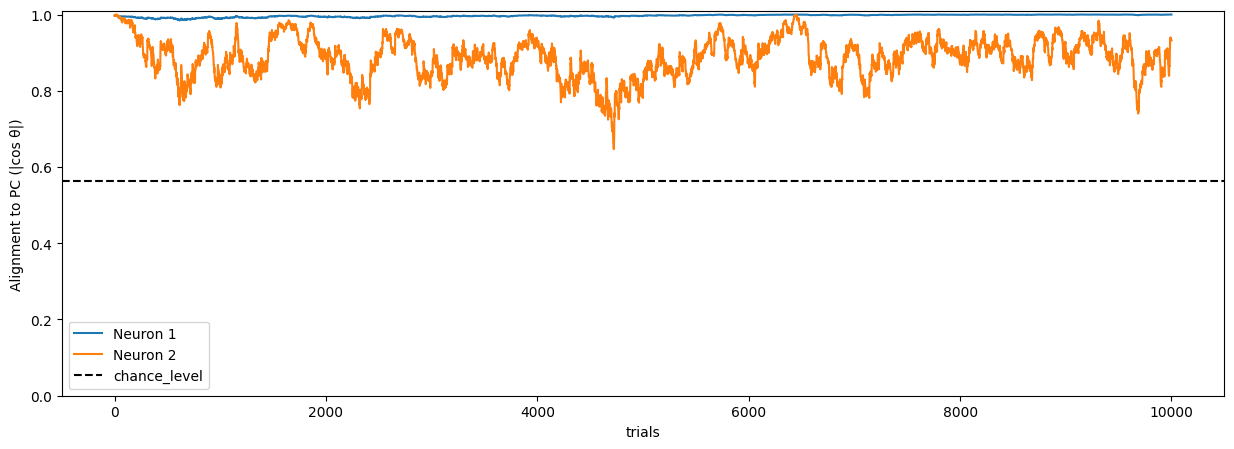

after second phase: model.W = [[-0.38275232 -0.69846346 -0.55662467]
 [ 0.4734392   0.36430014 -0.79408884]]; model.V = [[0.        0.0757608]
 [0.0757608 0.       ]]
run  4
X_before
step    0 | order = [1 0] | best|corr|= [0.975 0.381]
step 1000 | order = [0 1] | best|corr|= [0.875 0.945]
step 2000 | order = [0 1] | best|corr|= [0.843 0.976]
step 3000 | order = [0 1] | best|corr|= [0.881 0.987]
step 4000 | order = [0 1] | best|corr|= [0.91  0.991]
step 5000 | order = [0 1] | best|corr|= [0.929 0.993]
step 6000 | order = [0 1] | best|corr|= [0.939 0.994]
step 7000 | order = [0 1] | best|corr|= [0.972 0.995]
step 8000 | order = [0 1] | best|corr|= [0.999 0.996]
step 9000 | order = [0 1] | best|corr|= [0.995 0.996]
step 10000 | order = [0 1] | best|corr|= [0.98  0.997]


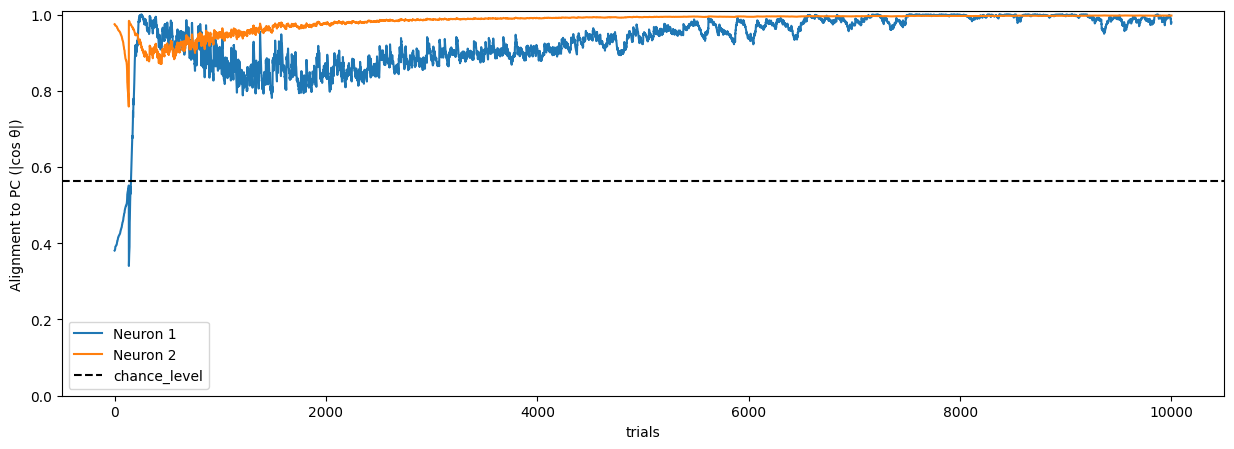

X_after
step    0 | order = [0 1] | best|corr|= [1.    0.909]
step 1000 | order = [0 1] | best|corr|= [0.882 0.944]
step 2000 | order = [0 1] | best|corr|= [0.933 0.944]
step 3000 | order = [0 1] | best|corr|= [0.948 0.886]
step 4000 | order = [0 1] | best|corr|= [0.974 0.916]
step 5000 | order = [0 1] | best|corr|= [0.976 0.822]
step 6000 | order = [0 1] | best|corr|= [0.986 0.843]
step 7000 | order = [0 1] | best|corr|= [0.993 0.879]
step 8000 | order = [0 1] | best|corr|= [0.994 0.838]
step 9000 | order = [0 1] | best|corr|= [0.997 0.879]
step 10000 | order = [0 1] | best|corr|= [0.998 0.9  ]


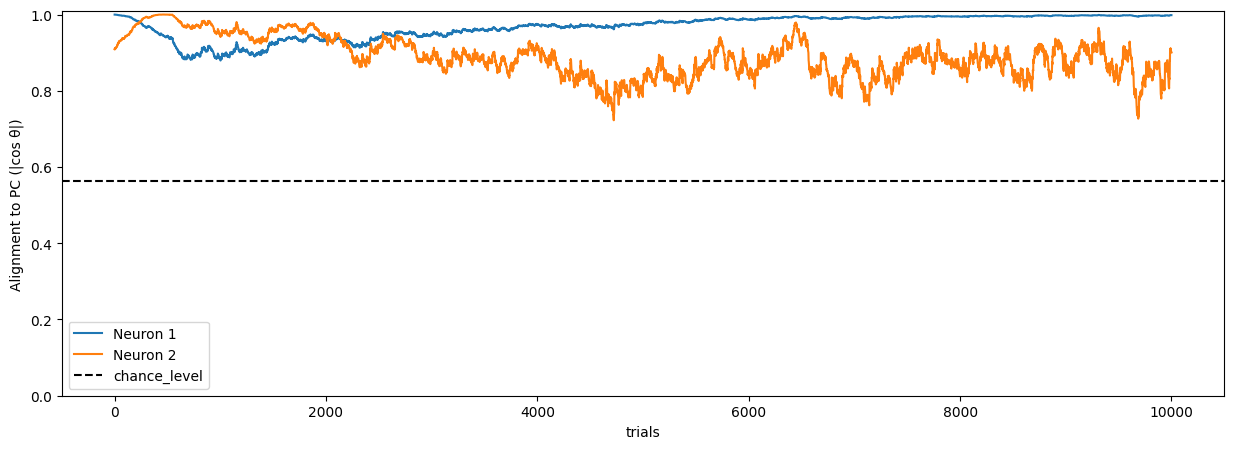

after second phase: model.W = [[ 0.26911009  0.40639883 -0.82147686]
 [-0.26025709 -0.76013158 -0.46035921]]; model.V = [[0.         0.15299496]
 [0.15299496 0.        ]]
run  5
X_before
step    0 | order = [1 0] | best|corr|= [0.999 0.54 ]
step 1000 | order = [0 1] | best|corr|= [0.632 0.988]
step 2000 | order = [0 1] | best|corr|= [0.619 0.991]
step 3000 | order = [0 1] | best|corr|= [0.611 0.992]
step 4000 | order = [0 1] | best|corr|= [0.616 0.994]
step 5000 | order = [0 1] | best|corr|= [0.604 0.995]
step 6000 | order = [0 1] | best|corr|= [0.612 0.995]
step 7000 | order = [0 1] | best|corr|= [0.623 0.996]
step 8000 | order = [0 1] | best|corr|= [0.655 0.996]
step 9000 | order = [0 1] | best|corr|= [0.657 0.997]
step 10000 | order = [0 1] | best|corr|= [0.717 0.997]


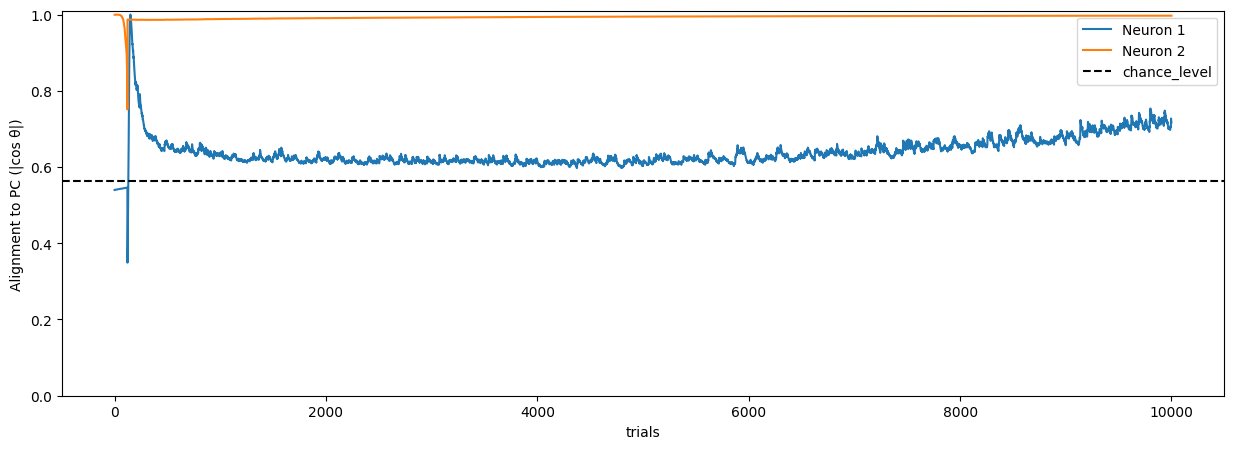

X_after
step    0 | order = [0 1] | best|corr|= [0.969 0.899]
step 1000 | order = [0 1] | best|corr|= [0.782 0.863]
step 2000 | order = [1 0] | best|corr|= [0.751 0.764]
step 3000 | order = [1 0] | best|corr|= [0.91  0.811]
step 4000 | order = [1 0] | best|corr|= [0.959 0.848]
step 5000 | order = [1 0] | best|corr|= [0.96  0.882]
step 6000 | order = [1 0] | best|corr|= [1.    0.908]
step 7000 | order = [1 0] | best|corr|= [0.999 0.93 ]
step 8000 | order = [1 0] | best|corr|= [1.    0.946]
step 9000 | order = [1 0] | best|corr|= [0.994 0.959]
step 10000 | order = [1 0] | best|corr|= [0.997 0.968]


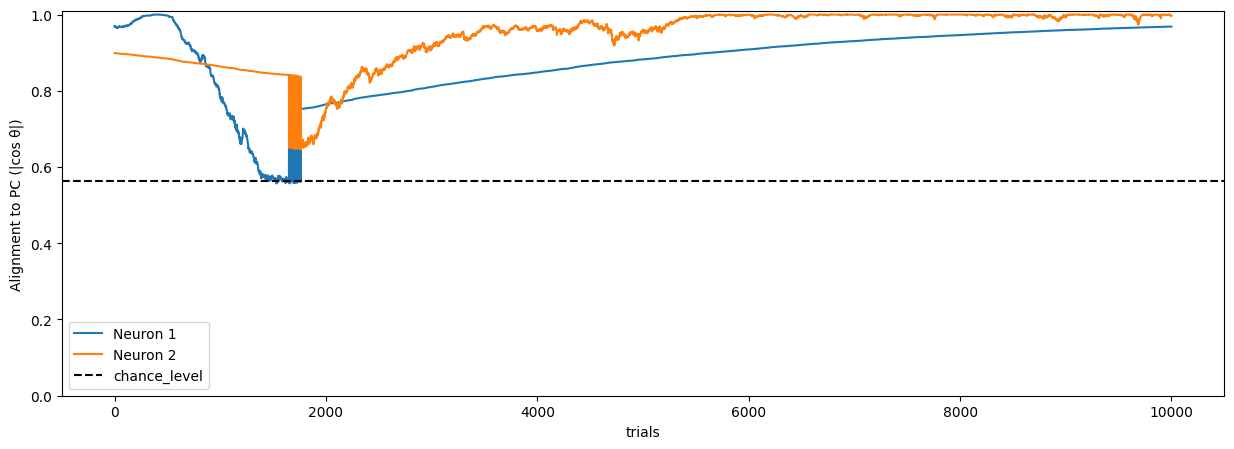

after second phase: model.W = [[-0.77786405  0.45881071 -0.25378302]
 [ 0.5394288   0.7660072  -0.34433124]]; model.V = [[ 0.         -0.04212941]
 [-0.04212941  0.        ]]
run  6
X_before
step    0 | order = [0 1] | best|corr|= [0.7   0.964]
step 1000 | order = [0 1] | best|corr|= [0.973 0.379]
step 2000 | order = [0 1] | best|corr|= [0.97  0.367]
step 3000 | order = [0 1] | best|corr|= [0.98  0.373]
step 4000 | order = [0 1] | best|corr|= [0.987 0.447]
step 5000 | order = [0 1] | best|corr|= [0.955 0.387]
step 6000 | order = [0 1] | best|corr|= [0.981 0.556]
step 7000 | order = [0 1] | best|corr|= [0.921 0.547]
step 8000 | order = [0 1] | best|corr|= [0.867 0.64 ]
step 9000 | order = [0 1] | best|corr|= [0.856 0.797]
step 10000 | order = [0 1] | best|corr|= [0.702 0.841]


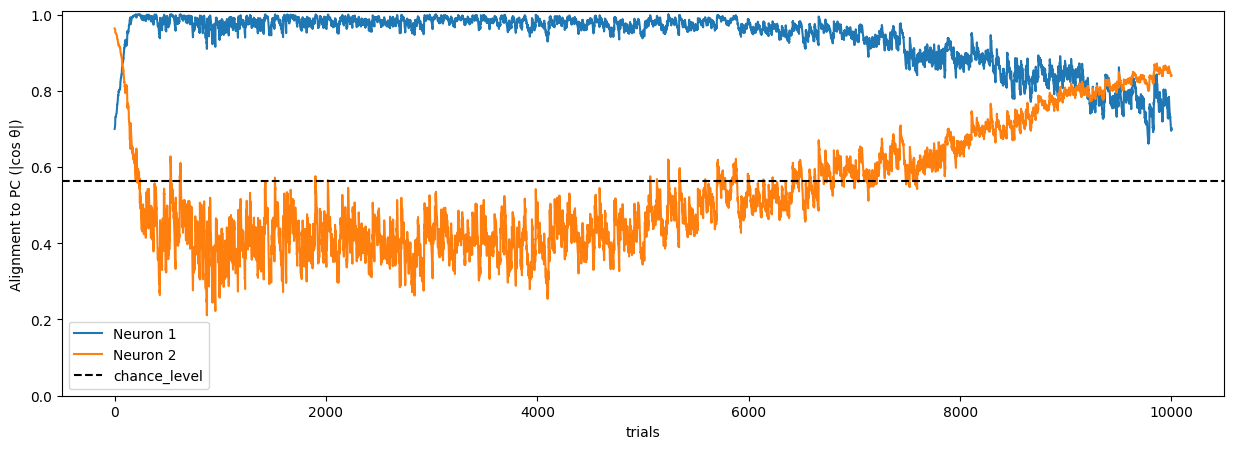

X_after
step    0 | order = [1 0] | best|corr|= [0.173 0.969]
step 1000 | order = [0 1] | best|corr|= [0.914 0.999]
step 2000 | order = [0 1] | best|corr|= [0.938 0.998]
step 3000 | order = [0 1] | best|corr|= [0.964 1.   ]
step 4000 | order = [0 1] | best|corr|= [0.972 0.997]
step 5000 | order = [0 1] | best|corr|= [0.983 0.99 ]
step 6000 | order = [0 1] | best|corr|= [0.984 1.   ]
step 7000 | order = [0 1] | best|corr|= [0.988 1.   ]
step 8000 | order = [0 1] | best|corr|= [0.992 0.988]
step 9000 | order = [0 1] | best|corr|= [0.992 0.996]
step 10000 | order = [0 1] | best|corr|= [0.994 0.994]


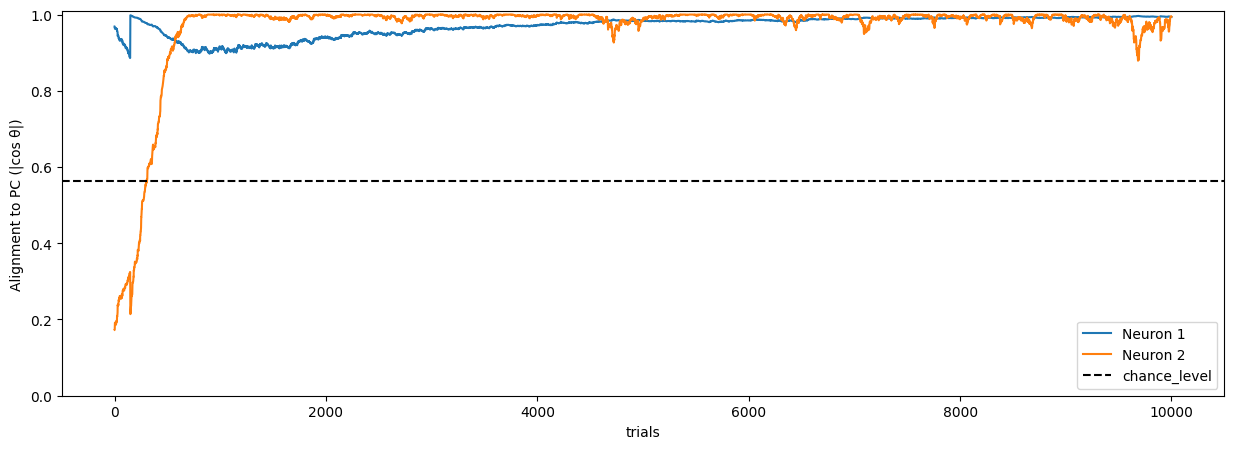

after second phase: model.W = [[-0.46207235 -0.49928595  0.68647372]
 [ 0.21134191  0.51761058  0.52209119]]; model.V = [[ 0.         -0.13931601]
 [-0.13931601  0.        ]]
run  7
X_before
step    0 | order = [0 1] | best|corr|= [0.556 0.991]
step 1000 | order = [1 0] | best|corr|= [0.961 0.852]
step 2000 | order = [1 0] | best|corr|= [0.976 0.837]
step 3000 | order = [1 0] | best|corr|= [0.983 0.854]
step 4000 | order = [1 0] | best|corr|= [0.988 0.867]
step 5000 | order = [1 0] | best|corr|= [0.99  0.874]
step 6000 | order = [1 0] | best|corr|= [0.992 0.888]
step 7000 | order = [1 0] | best|corr|= [0.993 0.924]
step 8000 | order = [1 0] | best|corr|= [0.994 0.974]
step 9000 | order = [1 0] | best|corr|= [0.995 0.966]
step 10000 | order = [1 0] | best|corr|= [0.996 1.   ]


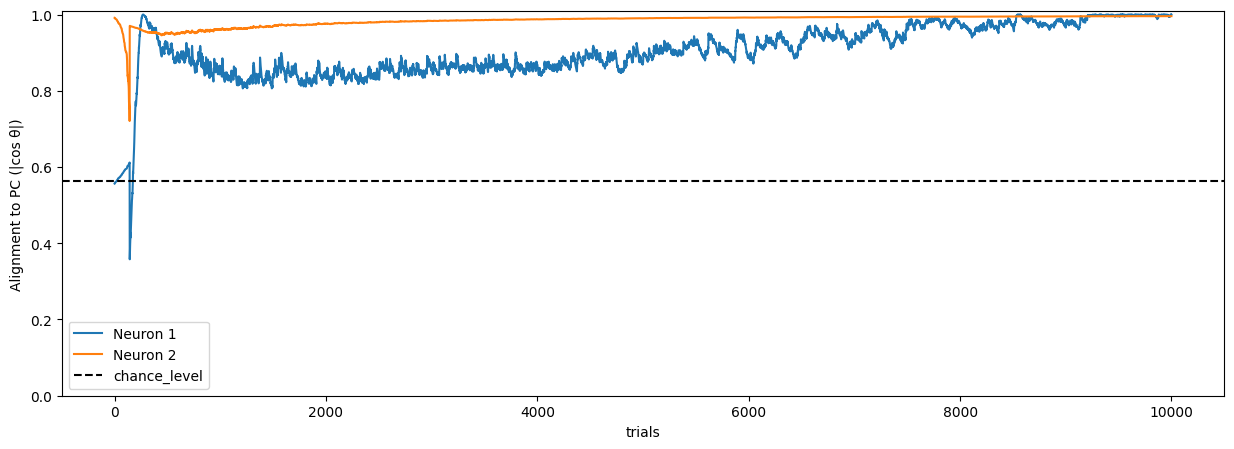

X_after
step    0 | order = [1 0] | best|corr|= [0.87 1.  ]
step 1000 | order = [1 0] | best|corr|= [0.946 0.439]
step 2000 | order = [0 1] | best|corr|= [0.579 0.844]
step 3000 | order = [0 1] | best|corr|= [0.631 0.914]
step 4000 | order = [0 1] | best|corr|= [0.701 0.948]
step 5000 | order = [0 1] | best|corr|= [0.775 0.988]
step 6000 | order = [0 1] | best|corr|= [0.827 0.997]
step 7000 | order = [0 1] | best|corr|= [0.88  0.984]
step 8000 | order = [0 1] | best|corr|= [0.916 0.986]
step 9000 | order = [0 1] | best|corr|= [0.939 0.961]
step 10000 | order = [0 1] | best|corr|= [0.955 0.959]


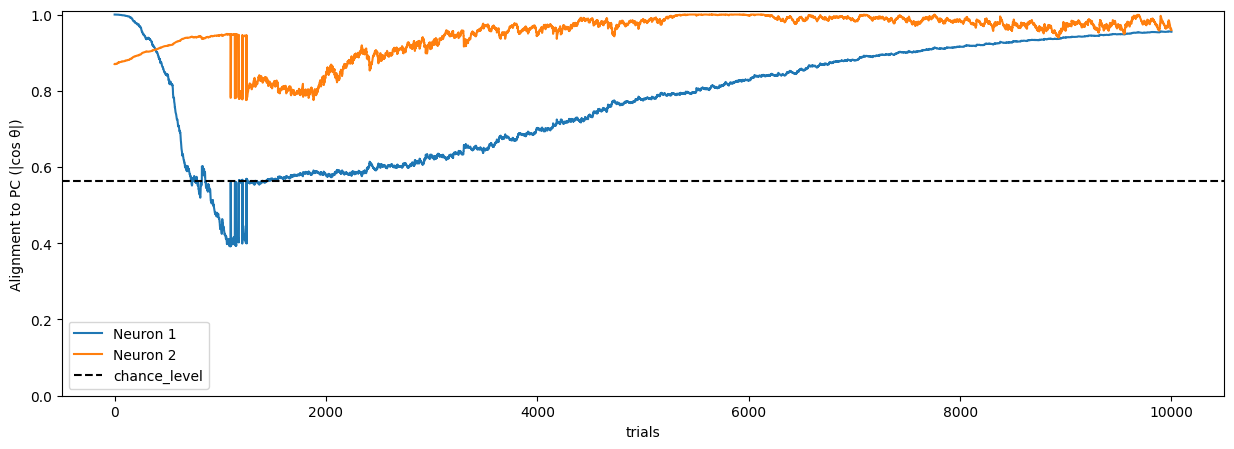

after second phase: model.W = [[ 0.59037762  0.68704527 -0.29649412]
 [-0.60950132  0.26940624 -0.41519472]]; model.V = [[ 0.         -0.29956521]
 [-0.29956521  0.        ]]
run  8
X_before
step    0 | order = [1 0] | best|corr|= [0.849 0.532]
step 1000 | order = [0 1] | best|corr|= [0.989 0.827]
step 2000 | order = [0 1] | best|corr|= [0.994 0.893]
step 3000 | order = [0 1] | best|corr|= [0.988 0.936]
step 4000 | order = [0 1] | best|corr|= [1.    0.948]
step 5000 | order = [0 1] | best|corr|= [1.    0.962]
step 6000 | order = [0 1] | best|corr|= [0.999 0.967]
step 7000 | order = [0 1] | best|corr|= [0.999 0.977]
step 8000 | order = [0 1] | best|corr|= [0.984 0.984]
step 9000 | order = [0 1] | best|corr|= [0.995 0.985]
step 10000 | order = [0 1] | best|corr|= [0.939 0.991]


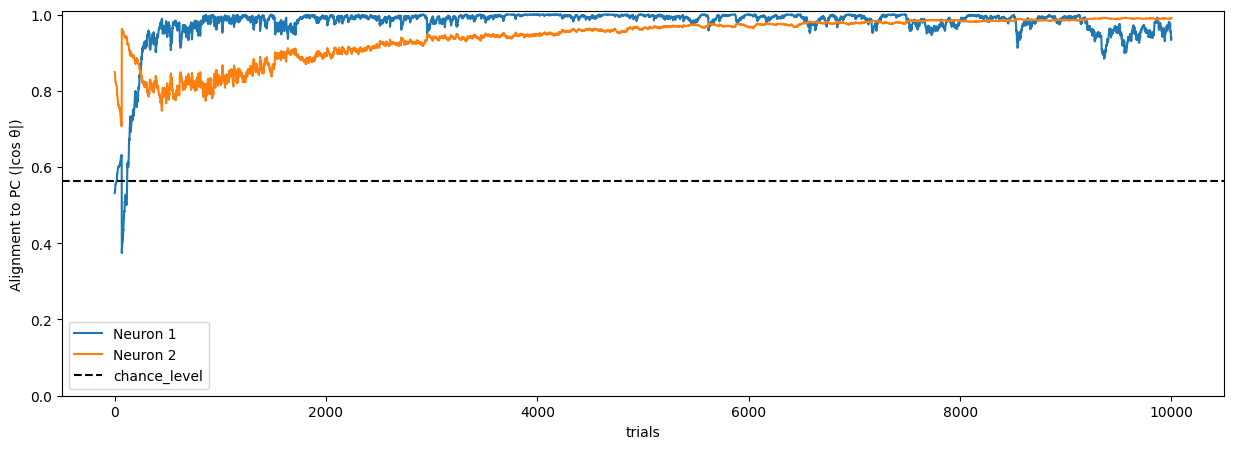

X_after
step    0 | order = [0 1] | best|corr|= [0.999 0.778]
step 1000 | order = [0 1] | best|corr|= [0.934 0.779]
step 2000 | order = [0 1] | best|corr|= [0.965 0.851]
step 3000 | order = [0 1] | best|corr|= [0.973 0.795]
step 4000 | order = [0 1] | best|corr|= [0.986 0.866]
step 5000 | order = [0 1] | best|corr|= [0.987 0.769]
step 6000 | order = [0 1] | best|corr|= [0.992 0.801]
step 7000 | order = [0 1] | best|corr|= [0.996 0.86 ]
step 8000 | order = [0 1] | best|corr|= [0.996 0.814]
step 9000 | order = [0 1] | best|corr|= [0.998 0.868]
step 10000 | order = [0 1] | best|corr|= [0.999 0.896]


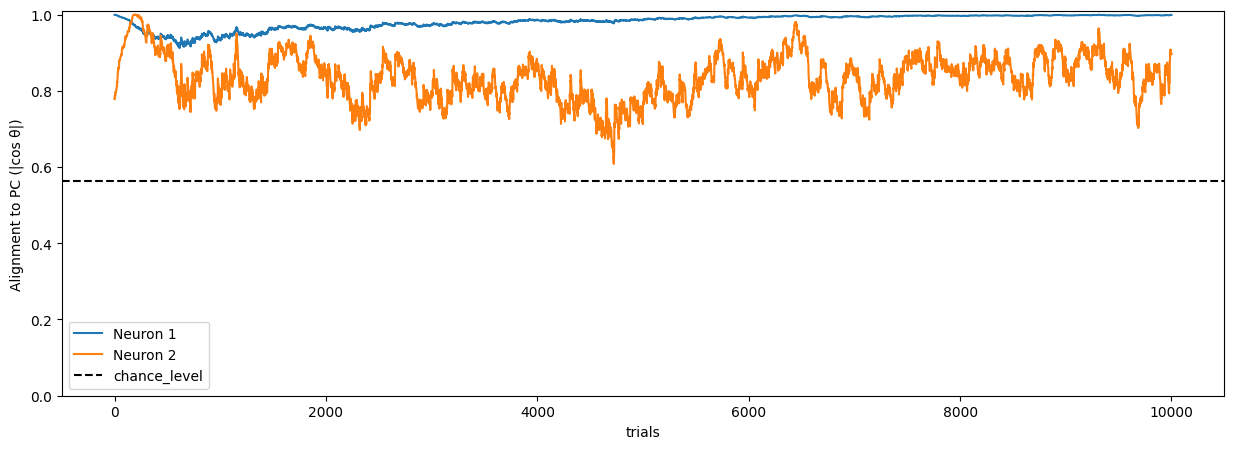

after second phase: model.W = [[-0.41684313 -0.34713187  0.81200902]
 [ 0.23824973  0.73782011  0.43964325]]; model.V = [[0.         0.14434307]
 [0.14434307 0.        ]]
run  9
X_before
step    0 | order = [1 0] | best|corr|= [0.998 0.563]
step 1000 | order = [1 0] | best|corr|= [0.954 0.147]
step 2000 | order = [0 1] | best|corr|= [0.253 0.914]
step 3000 | order = [0 1] | best|corr|= [0.317 0.931]
step 4000 | order = [0 1] | best|corr|= [0.357 0.892]
step 5000 | order = [0 1] | best|corr|= [0.374 0.901]
step 6000 | order = [0 1] | best|corr|= [0.39  0.829]
step 7000 | order = [1 0] | best|corr|= [1.    0.215]
step 8000 | order = [1 0] | best|corr|= [1.    0.271]
step 9000 | order = [1 0] | best|corr|= [1.    0.393]
step 10000 | order = [1 0] | best|corr|= [1.    0.382]


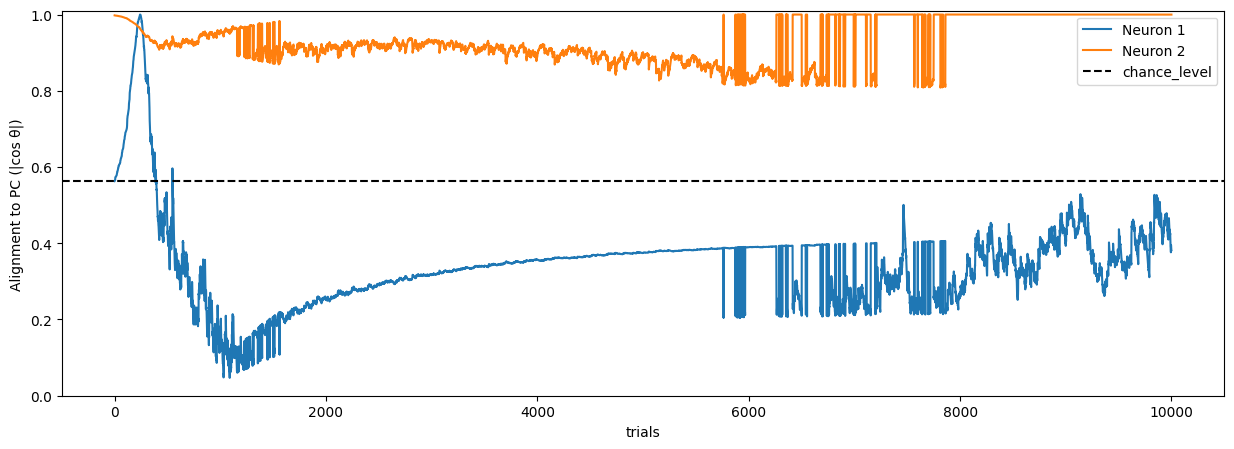

X_after
step    0 | order = [1 0] | best|corr|= [0.994 0.985]
step 1000 | order = [1 0] | best|corr|= [0.999 0.819]
step 2000 | order = [1 0] | best|corr|= [0.996 0.84 ]
step 3000 | order = [1 0] | best|corr|= [0.98  0.831]
step 4000 | order = [1 0] | best|corr|= [0.97  0.893]
step 5000 | order = [1 0] | best|corr|= [0.915 0.897]
step 6000 | order = [1 0] | best|corr|= [0.887 0.941]
step 7000 | order = [1 0] | best|corr|= [0.883 0.972]
step 8000 | order = [1 0] | best|corr|= [0.85  0.982]
step 9000 | order = [1 0] | best|corr|= [0.867 0.992]
step 10000 | order = [1 0] | best|corr|= [0.874 0.996]


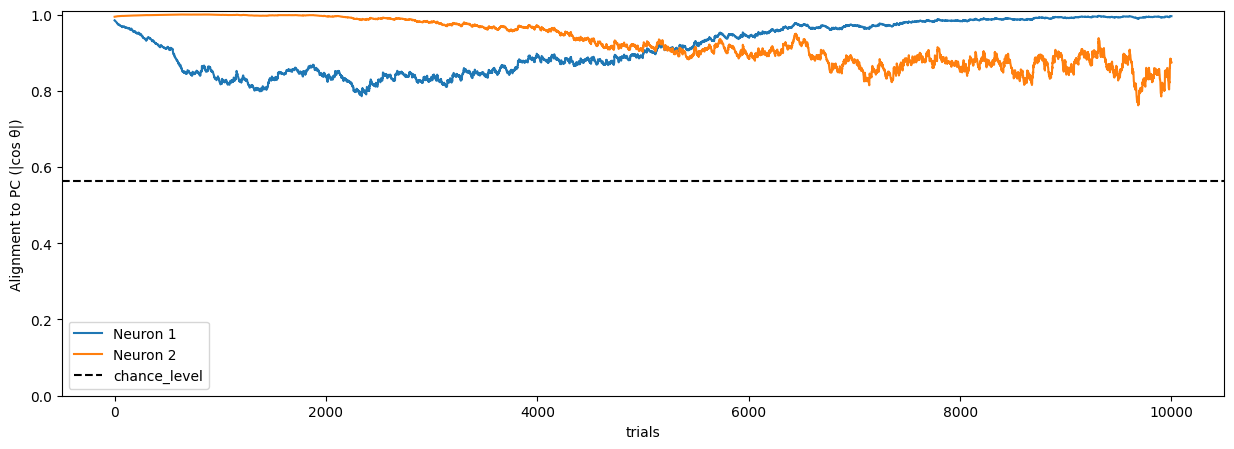

after second phase: model.W = [[ 0.23957901  0.78650506  0.44075803]
 [ 0.02308715 -0.51471142  0.73339276]]; model.V = [[0.         0.23072297]
 [0.23072297 0.        ]]
run 10
X_before
step    0 | order = [0 1] | best|corr|= [0.478 0.988]
step 1000 | order = [1 0] | best|corr|= [0.853 0.966]
step 2000 | order = [1 0] | best|corr|= [0.927 0.91 ]
step 3000 | order = [1 0] | best|corr|= [0.96  0.902]
step 4000 | order = [1 0] | best|corr|= [0.976 0.915]
step 5000 | order = [1 0] | best|corr|= [0.982 0.915]
step 6000 | order = [1 0] | best|corr|= [0.986 0.922]
step 7000 | order = [1 0] | best|corr|= [0.989 0.957]
step 8000 | order = [1 0] | best|corr|= [0.992 0.992]
step 9000 | order = [1 0] | best|corr|= [0.993 0.985]
step 10000 | order = [1 0] | best|corr|= [0.995 0.993]


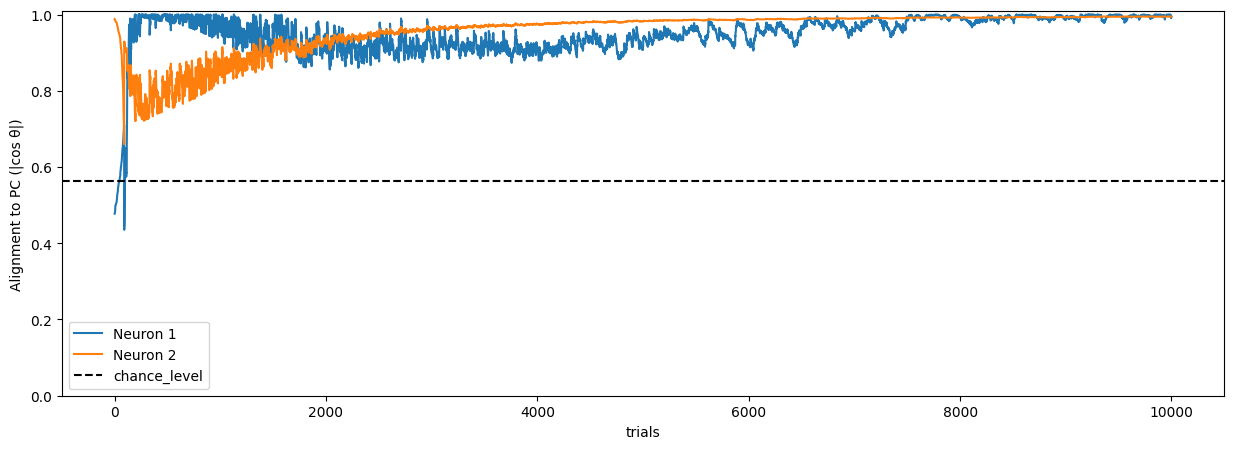

X_after
step    0 | order = [1 0] | best|corr|= [0.846 1.   ]
step 1000 | order = [1 0] | best|corr|= [0.964 0.784]
step 2000 | order = [1 0] | best|corr|= [0.957 0.869]
step 3000 | order = [1 0] | best|corr|= [0.899 0.901]
step 4000 | order = [1 0] | best|corr|= [0.913 0.949]
step 5000 | order = [1 0] | best|corr|= [0.82  0.957]
step 6000 | order = [1 0] | best|corr|= [0.816 0.974]
step 7000 | order = [1 0] | best|corr|= [0.852 0.986]
step 8000 | order = [1 0] | best|corr|= [0.811 0.989]
step 9000 | order = [1 0] | best|corr|= [0.852 0.994]
step 10000 | order = [1 0] | best|corr|= [0.878 0.997]


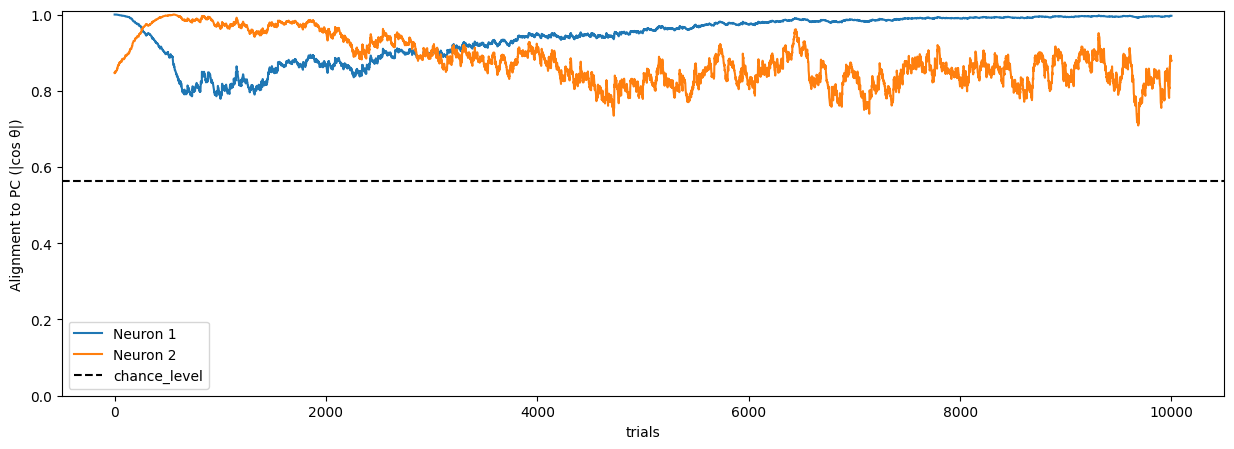

after second phase: model.W = [[-0.35629581 -0.67835439 -0.44362981]
 [ 0.32598702  0.33287685 -0.80422714]]; model.V = [[0.        0.1966297]
 [0.1966297 0.       ]]


<Figure size 640x480 with 0 Axes>

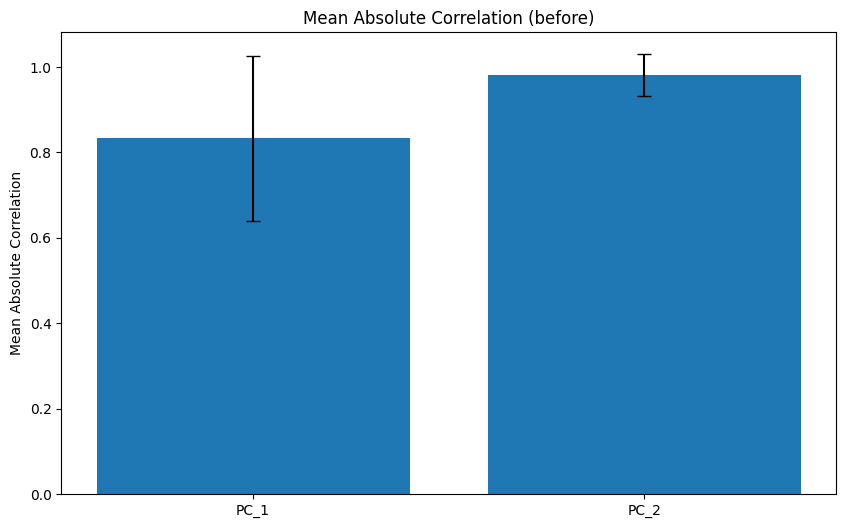

<Figure size 640x480 with 0 Axes>

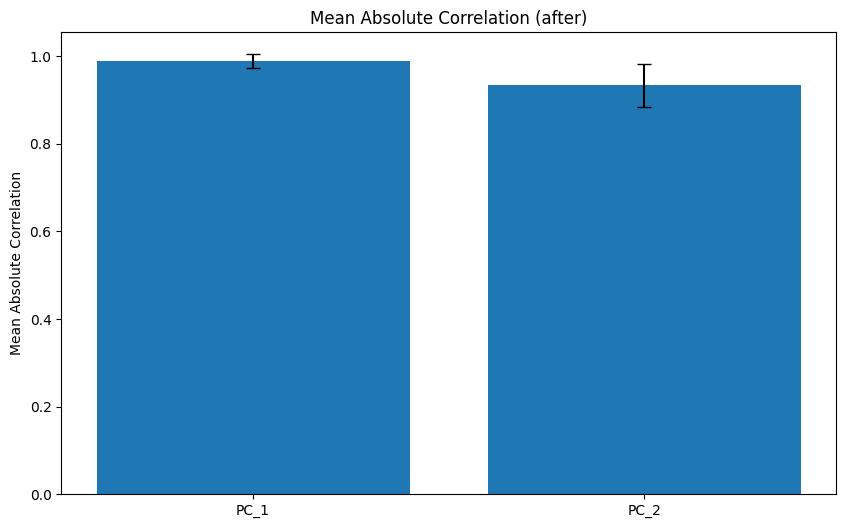

In [6]:
leen_model  = LeenCompletePCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = None, runs = 10, graph = True)